<a href="https://colab.research.google.com/github/Liebestraum09/geometric-shapes-classification/blob/main/Geometric_Shapes_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

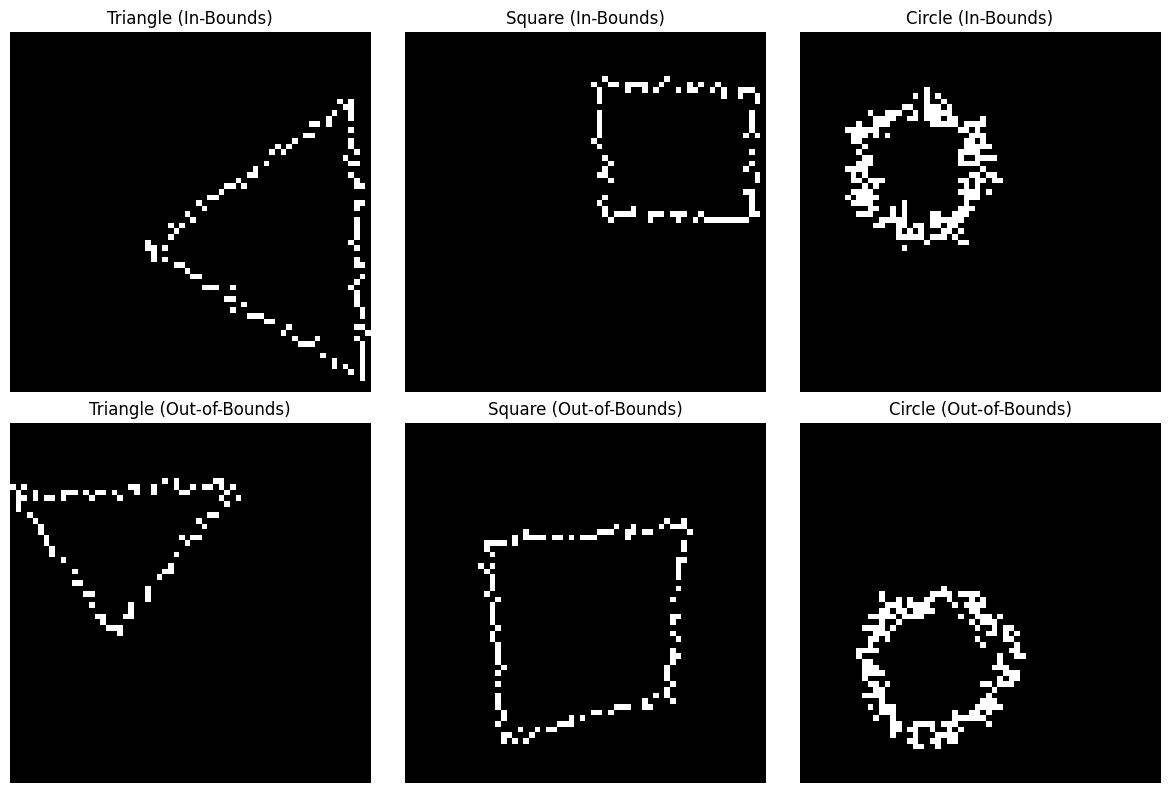

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def draw_shape_outline(size=32, shape_type="triangle", verticies_noise_level=0, line_noise_level=0, allow_out_of_bounds=False):

    img = np.zeros((size, size))
    center = size // 2

    # Calculate random translation (within ±30% of size)
    max_translation = size * 0.3  # 30% of image size
    dx = np.random.uniform(-max_translation, max_translation)
    dy = np.random.uniform(-max_translation, max_translation)

    if shape_type == "triangle":
        # Define base triangle vertices (equilateral-like) with float dtype
        # Replace 0.7 with random float between 0.3 and 1 (exclusive), rounded to 2 decimals
        random_ratio = round(np.random.uniform(0.3, 1), 2)
        height = int(center * random_ratio)
        width = int(center * random_ratio)
        top = np.array([center, center - height], dtype=np.float64)
        bottom_left = np.array([center - width, center + height//2], dtype=np.float64)
        bottom_right = np.array([center + width, center + height//2], dtype=np.float64)

        # Apply translation
        top += [dx, dy]
        bottom_left += [dx, dy]
        bottom_right += [dx, dy]

        # Apply noise to vertices
        top += np.random.normal(0, verticies_noise_level, 2)
        bottom_left += np.random.normal(0, verticies_noise_level, 2)
        bottom_right += np.random.normal(0, verticies_noise_level, 2)

        # Draw lines between perturbed vertices
        draw_line(img, tuple(top.astype(int)), tuple(bottom_left.astype(int)), line_noise_level, allow_out_of_bounds)
        draw_line(img, tuple(bottom_left.astype(int)), tuple(bottom_right.astype(int)), line_noise_level, allow_out_of_bounds)
        draw_line(img, tuple(bottom_right.astype(int)), tuple(top.astype(int)), line_noise_level, allow_out_of_bounds)

    elif shape_type == "square":
        # Define base square vertices with float dtype
        # Replace 0.8 with random float between 0.3 and 1 (exclusive), rounded to 2 decimals
        random_ratio = round(np.random.uniform(0.3, 1), 2)
        half_side = int(center * random_ratio)
        top_left = np.array([center - half_side, center - half_side], dtype=np.float64)
        top_right = np.array([center + half_side, center - half_side], dtype=np.float64)
        bottom_left = np.array([center - half_side, center + half_side], dtype=np.float64)
        bottom_right = np.array([center + half_side, center + half_side], dtype=np.float64)

        # Apply translation
        top_left += [dx, dy]
        top_right += [dx, dy]
        bottom_left += [dx, dy]
        bottom_right += [dx, dy]

        # Apply noise to vertices
        top_left += np.random.normal(0, verticies_noise_level, 2)
        top_right += np.random.normal(0, verticies_noise_level, 2)
        bottom_left += np.random.normal(0, verticies_noise_level, 2)
        bottom_right += np.random.normal(0, verticies_noise_level, 2)

        # Draw lines between perturbed vertices
        draw_line(img, tuple(top_left.astype(int)), tuple(top_right.astype(int)), line_noise_level, allow_out_of_bounds)
        draw_line(img, tuple(top_right.astype(int)), tuple(bottom_right.astype(int)), line_noise_level, allow_out_of_bounds)
        draw_line(img, tuple(bottom_right.astype(int)), tuple(bottom_left.astype(int)), line_noise_level, allow_out_of_bounds)
        draw_line(img, tuple(bottom_left.astype(int)), tuple(top_left.astype(int)), line_noise_level, allow_out_of_bounds)

    elif shape_type == "circle":
        # Draw circle outline with per-point radius noise
        # Replace 0.8 with random float between 0.3 and 1 (exclusive), rounded to 2 decimals
        random_ratio = round(np.random.uniform(0.3, 1), 2)
        base_radius = int(center * random_ratio)
        num_points = 100  # Number of points for smooth circle
        prev_point = None
        for theta in np.linspace(0, 2 * np.pi, num_points, endpoint=False):
            # Apply noise to radius for distortion
            radius = base_radius + np.random.normal(0, verticies_noise_level)
            x = center + radius * np.cos(theta)
            y = center + radius * np.sin(theta)
            # Apply translation to current point
            x += dx
            y += dy
            current_point = (int(x), int(y))

            # Draw line to previous point to connect outline
            if prev_point is not None:
                draw_line(img, prev_point, current_point, line_noise_level, allow_out_of_bounds)
            prev_point = current_point

        # Close the circle by connecting last to first
        if prev_point is not None:
            first_x = center + base_radius * np.cos(0) + np.random.normal(0, verticies_noise_level) + dx
            first_y = center + base_radius * np.sin(0) + np.random.normal(0, verticies_noise_level) + dy
            draw_line(img, prev_point, (int(first_x), int(first_y)), line_noise_level, allow_out_of_bounds)

    # Random rotation (0, 90, 180, or 270 degrees clockwise)
    rotation_count = np.random.randint(0, 4)  # 0 to 3 rotations (0°, 90°, 180°, 270°)
    img = np.rot90(img, k=rotation_count)

    return img

def draw_line(img, p1, p2, noise_level=0, allow_out_of_bounds=False):
    """Draw a line between two points on the image using Bresenham's algorithm."""
    x1, y1 = p1
    x2, y2 = p2
    size = img.shape[0]

    # Ensure coordinates are within bounds only if not allowing out of bounds
    if not allow_out_of_bounds:
        x1 = max(0, min(size - 1, x1))
        y1 = max(0, min(size - 1, y1))
        x2 = max(0, min(size - 1, x2))
        y2 = max(0, min(size - 1, y2))

    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1
    err = dx - dy

    while True:
        if not allow_out_of_bounds and (0 <= x1 < size and 0 <= y1 < size):
            # Apply noise to the current position
            noisy_x = x1 + np.random.normal(0, noise_level)
            noisy_y = y1 + np.random.normal(0, noise_level)
            # Round to nearest integer and ensure within bounds
            noisy_x = max(0, min(size - 1, round(noisy_x)))
            noisy_y = max(0, min(size - 1, round(noisy_y)))
            img[int(noisy_y), int(noisy_x)] = 1.0
        elif allow_out_of_bounds and (0 <= x1 < size and 0 <= y1 < size):
            # Apply noise to the current position
            noisy_x = x1 + np.random.normal(0, noise_level)
            noisy_y = y1 + np.random.normal(0, noise_level)
            # Round to nearest integer (no bounds check if out of bounds allowed)
            noisy_x = round(noisy_x)
            noisy_y = round(noisy_y)
            if 0 <= noisy_x < size and 0 <= noisy_y < size:
                img[int(noisy_y), int(noisy_x)] = 1.0
        if x1 == x2 and y1 == y2:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x1 += sx
        if e2 < dx:
            err += dx
            y1 += sy

if __name__ == "__main__":
    # Set random seed for reproducibility in samples
    np.random.seed(42)

    # Define shapes and noise levels
    shapes = ["triangle", "square", "circle"]
    verticies_noise_level = 1.5  # Adjust this value to control vertex distortion
    line_noise_level = 0.5  # Adjust this value to control line distortion

    # Create subplots for samples with and without out-of-bounds
    fig, axs = plt.subplots(2, len(shapes), figsize=(12, 8))

    for i, shape in enumerate(shapes):
        # Without out-of-bounds
        img1 = draw_shape_outline(size=64, shape_type=shape, verticies_noise_level=verticies_noise_level, line_noise_level=line_noise_level, allow_out_of_bounds=True)
        axs[0, i].imshow(img1, cmap='gray')
        axs[0, i].set_title(f"{shape.capitalize()} (In-Bounds)")
        axs[0, i].axis('off')

        # With out-of-bounds
        img2 = draw_shape_outline(size=64, shape_type=shape, verticies_noise_level=verticies_noise_level, line_noise_level=line_noise_level, allow_out_of_bounds=True)
        axs[1, i].imshow(img2, cmap='gray')
        axs[1, i].set_title(f"{shape.capitalize()} (Out-of-Bounds)")
        axs[1, i].axis('off')

    plt.tight_layout()
    plt.show()

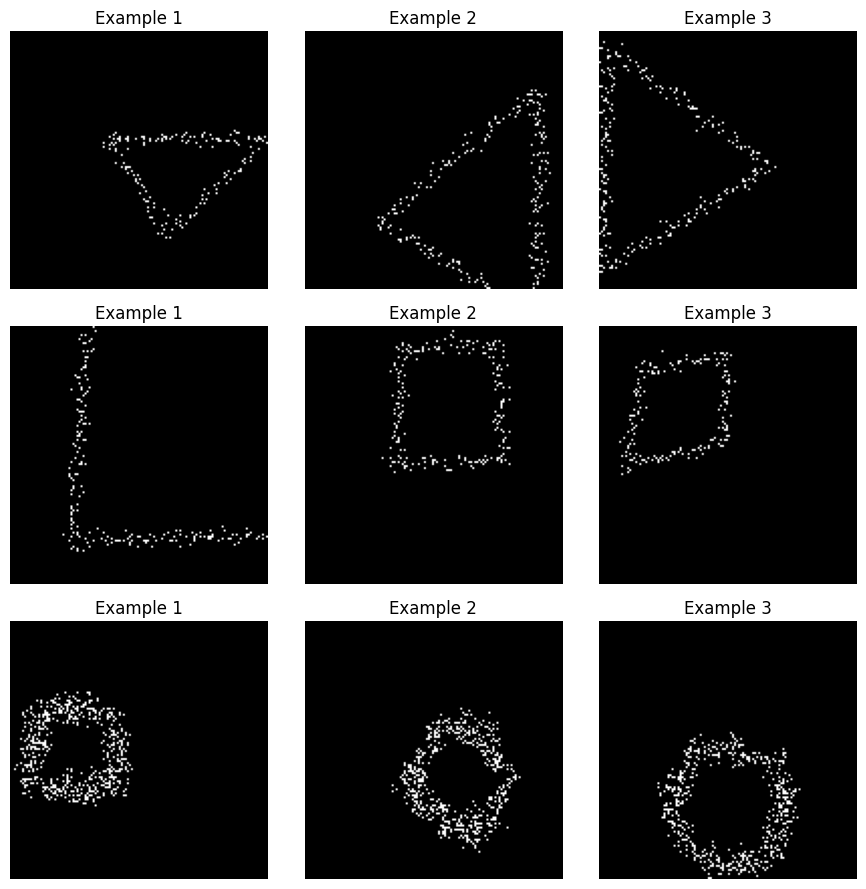

In [ ]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# Parameters
num_samples_per_shape = 50
shapes = ["triangle", "square", "circle"]
size = 128
verticies_noise_level = 4.0
line_noise_level = 2.0

NUM_FEATURES = size*size
NUM_CLASSES = 3
RANDOM_SEED = 42

# Initialize lists to hold images and labels
images = []
labels = []

# Generate samples for each shape
for label, shape in enumerate(shapes):
    for _ in range(num_samples_per_shape):
        # Generate one image; noise will vary naturally per call
        img = draw_shape_outline(size=size, shape_type=shape, verticies_noise_level=verticies_noise_level, line_noise_level=line_noise_level, allow_out_of_bounds= True)
        images.append(img)
        labels.append(label)  # 0: triangle, 1: square, 2: circle

# Convert to NumPy arrays
images_np = np.array(images)  # Shape: (150, 32, 32)
labels_np = np.array(labels)  # Shape: (150,)

# Convert to PyTorch tensors
# Add channel dimension for typical ML input (e.g., for CNNs)
images_tensor = torch.from_numpy(images_np).float().unsqueeze(1)  # Shape: (150, 1, 32, 32)
labels_tensor = torch.from_numpy(labels_np).long()  # Shape: (150,)

# Optional: Shuffle the dataset for training
indices = torch.randperm(len(images_tensor))
images_tensor = images_tensor[indices]
labels_tensor = labels_tensor[indices]

# 3. Split into train and test sets
images_tensor_train, images_tensor_test, labels_tensor_train, labels_tensor_test = train_test_split(images_tensor,
    labels_tensor,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# Visualize three example images for each shape
fig, axs = plt.subplots(len(shapes), 3, figsize=(9, 9))
for i, shape in enumerate(shapes):
    # Generate three new example images for visualization
    for j in range(3):
        img = draw_shape_outline(size=size, shape_type=shape, verticies_noise_level=verticies_noise_level, line_noise_level=line_noise_level, allow_out_of_bounds= True)
        axs[i, j].imshow(img, cmap='gray')
        if j == 0:
            axs[i, j].set_ylabel(f"{shape.capitalize()}", fontsize=12)
        axs[i, j].set_title(f"Example {j+1}")
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
import torch
from torch import nn

class CNN_Model(nn.Module):
    def __init__(self, input_channels, output_features, hidden_units=128):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=input_channels, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),  # 50% drop-out
            nn.Linear(in_features=hidden_units * 32 * 32, out_features=output_features)
        )

    def forward(self, x):
        x = self.conv_block(x)
        return self.classifier(x)

# Model Reset
model_0 = CNN_Model(input_channels=1, output_features=NUM_CLASSES, hidden_units=128).to(device)


In [ ]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

In [ ]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_0(images_tensor_train.to(device))[:5]

tensor([[-0.0611, -0.0059, -0.0285],
        [-0.0725, -0.0216, -0.0599],
        [ 0.0287, -0.0979, -0.0456],
        [-0.0831, -0.1345,  0.0784],
        [ 0.0054,  0.0114,  0.1449]], grad_fn=<SliceBackward0>)

In [ ]:
# Make prediction logits with model
image_logits = model_0(images_tensor_train.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
image_pred_probs = torch.softmax(image_logits, dim=1)
print(image_logits[:5])
print(image_pred_probs[:5])
image_pred_probs.shape

tensor([[ 0.0240, -0.1053, -0.0607],
        [-0.0559, -0.0354,  0.0388],
        [-0.0054, -0.0095, -0.1115],
        [ 0.1535, -0.0160,  0.0024],
        [-0.0558, -0.0384,  0.0042]], grad_fn=<SliceBackward0>)
tensor([[0.3575, 0.3141, 0.3284],
        [0.3205, 0.3271, 0.3524],
        [0.3454, 0.3440, 0.3106],
        [0.3698, 0.3122, 0.3180],
        [0.3248, 0.3304, 0.3448]], grad_fn=<SliceBackward0>)


torch.Size([120, 3])

In [ ]:
# Sum the first sample output of the softmax activation function
torch.sum(image_pred_probs[0])

tensor(1., grad_fn=<SumBackward0>)

In [ ]:
# Which class does the model think is *most* likely at the index 0 sample?
print(image_pred_probs[0])
print(torch.argmax(image_pred_probs[0]))

tensor([0.3575, 0.3141, 0.3284], grad_fn=<SelectBackward0>)
tensor(0)


In [ ]:
# Calculate accuracy (a classification metric)
def accuracy_fn(image_true, image_pred):
    correct = torch.eq(image_true, image_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(image_pred)) * 100
    return acc

Epoch: 0 | Loss: 1.09505, Acc: 35.00% | Test Loss: 4.33233, Test Acc: 26.67%


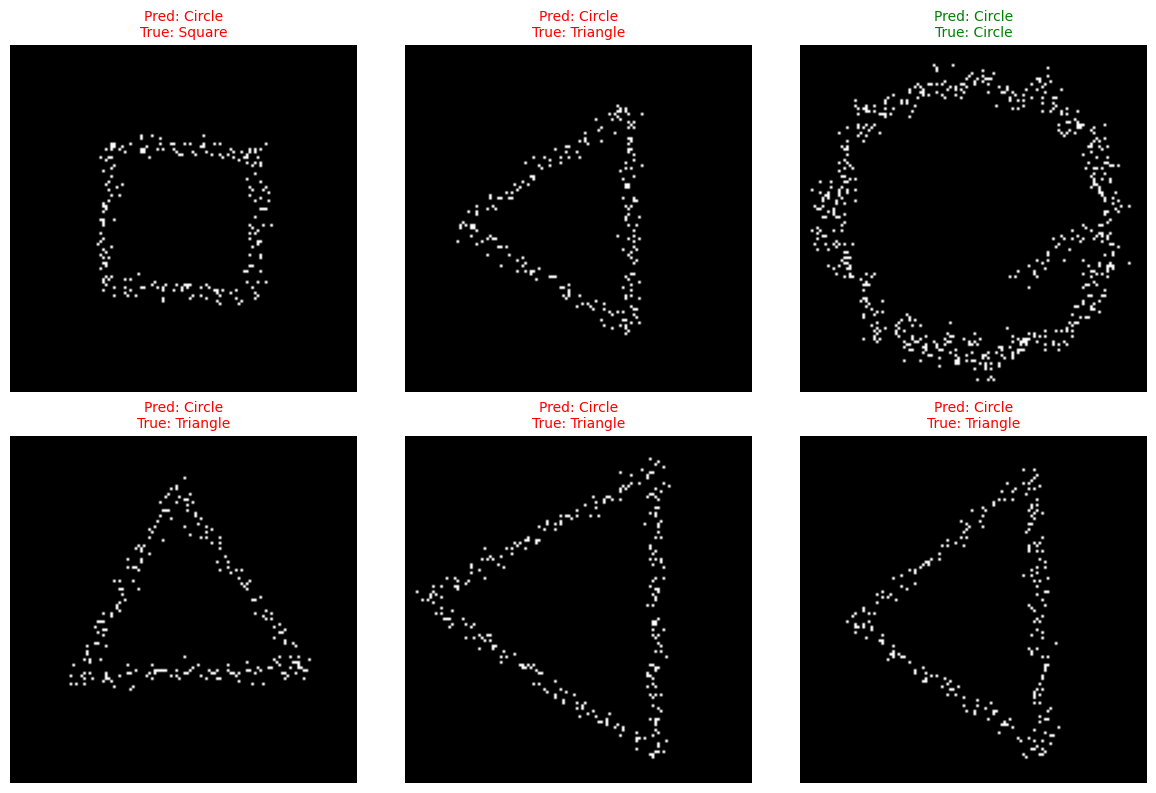

Epoch: 100 | Loss: 0.00230, Acc: 100.00% | Test Loss: 0.37466, Test Acc: 83.33%


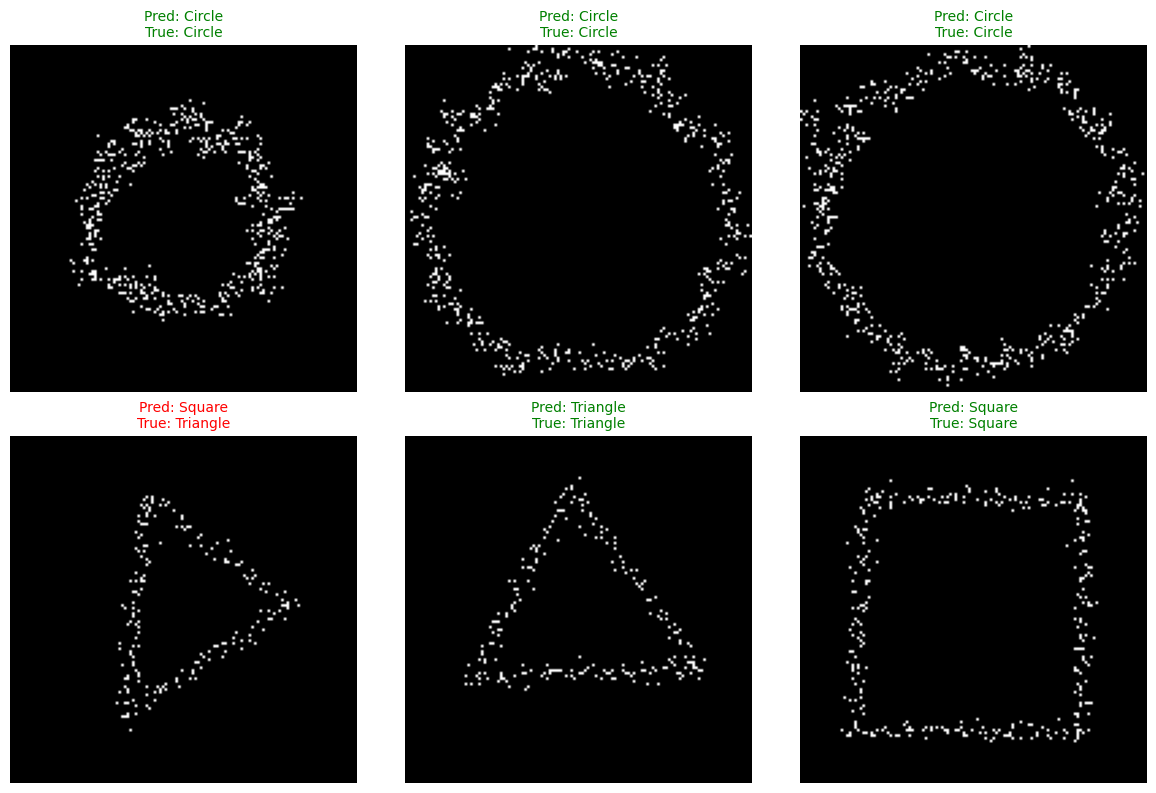

Epoch: 200 | Loss: 0.00283, Acc: 100.00% | Test Loss: 0.31227, Test Acc: 86.67%


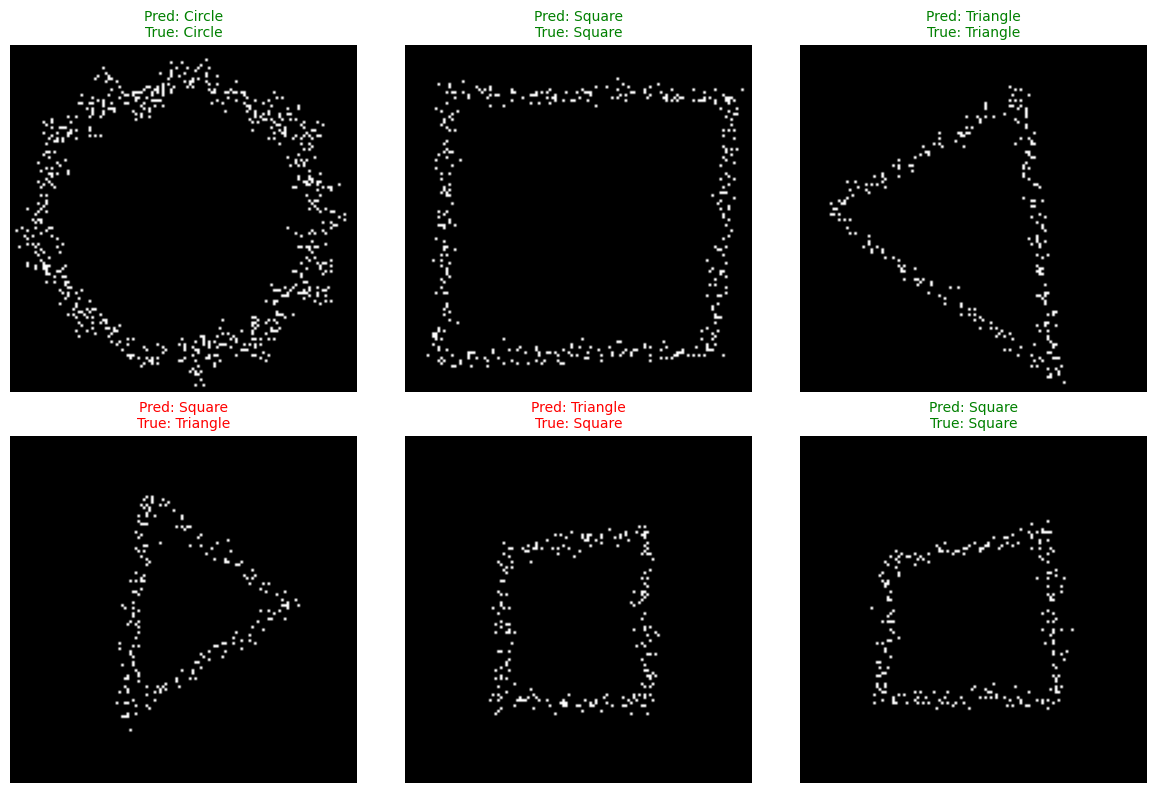

Epoch: 300 | Loss: 0.00293, Acc: 100.00% | Test Loss: 0.28481, Test Acc: 90.00%


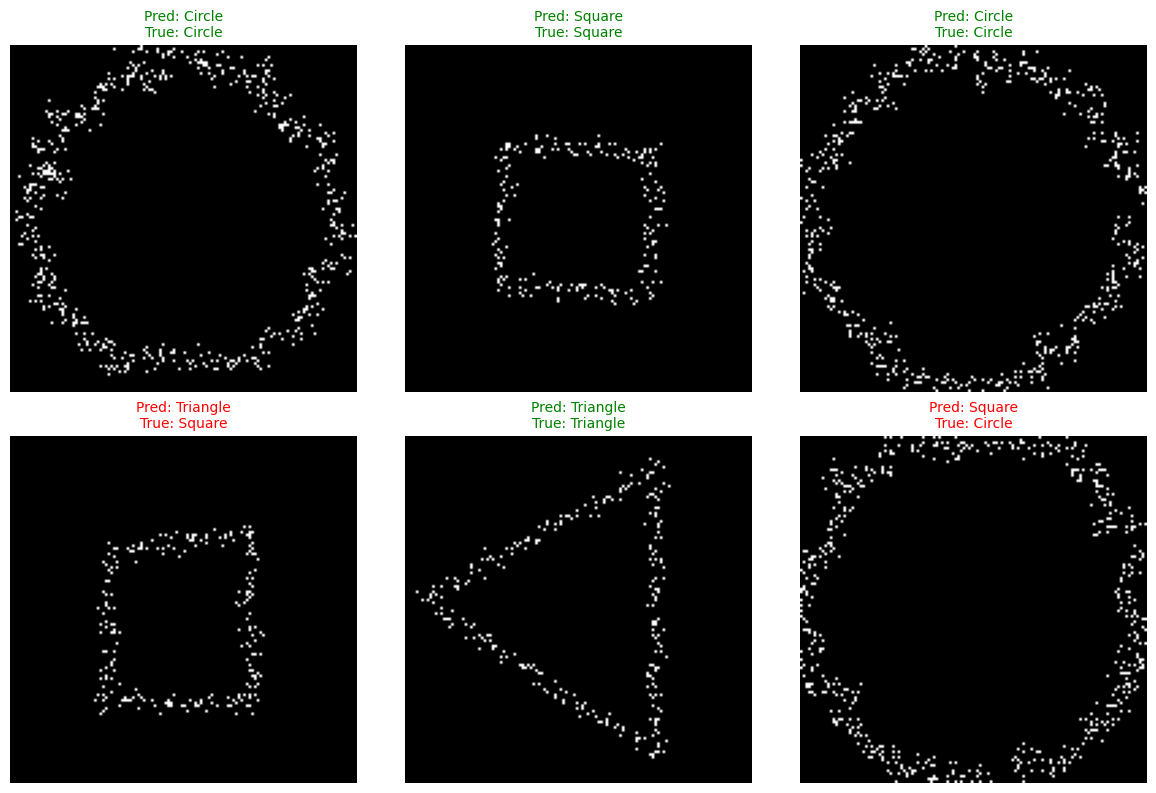

Epoch: 400 | Loss: 0.00320, Acc: 100.00% | Test Loss: 0.29168, Test Acc: 86.67%


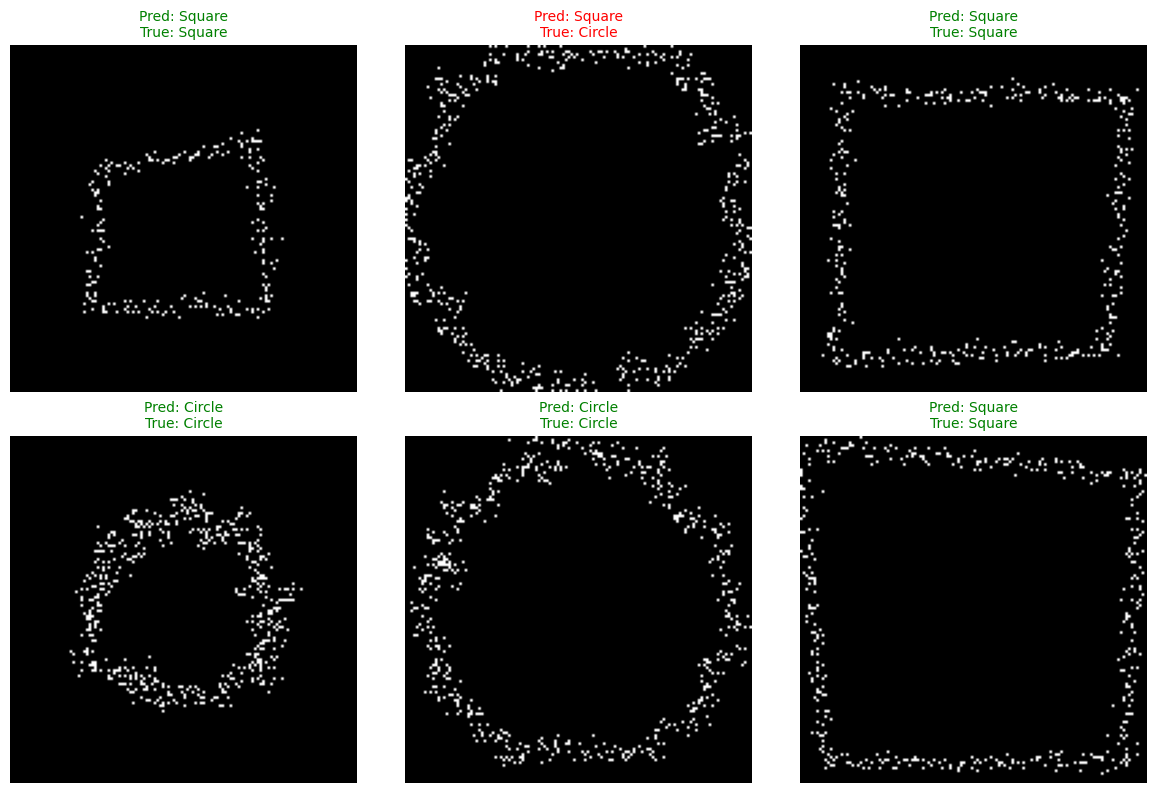

Epoch: 500 | Loss: 0.00344, Acc: 100.00% | Test Loss: 0.28798, Test Acc: 86.67%


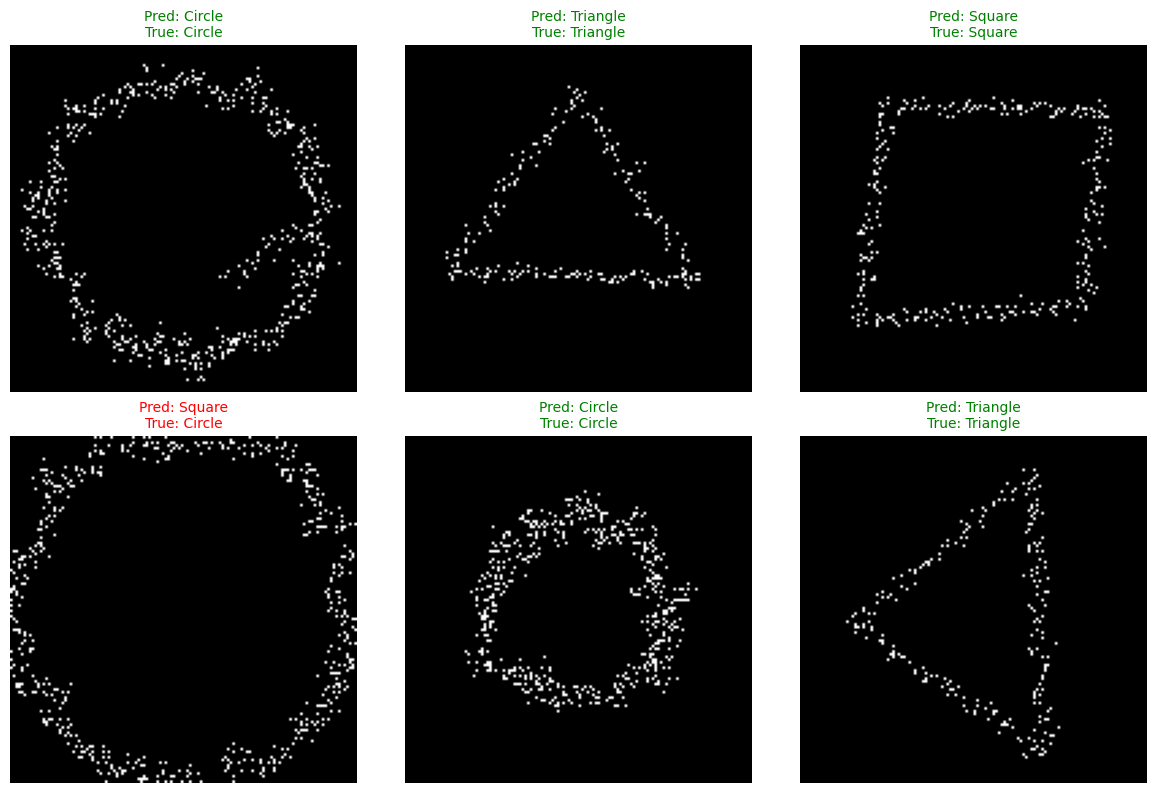

Epoch: 600 | Loss: 0.00344, Acc: 100.00% | Test Loss: 0.27525, Test Acc: 90.00%


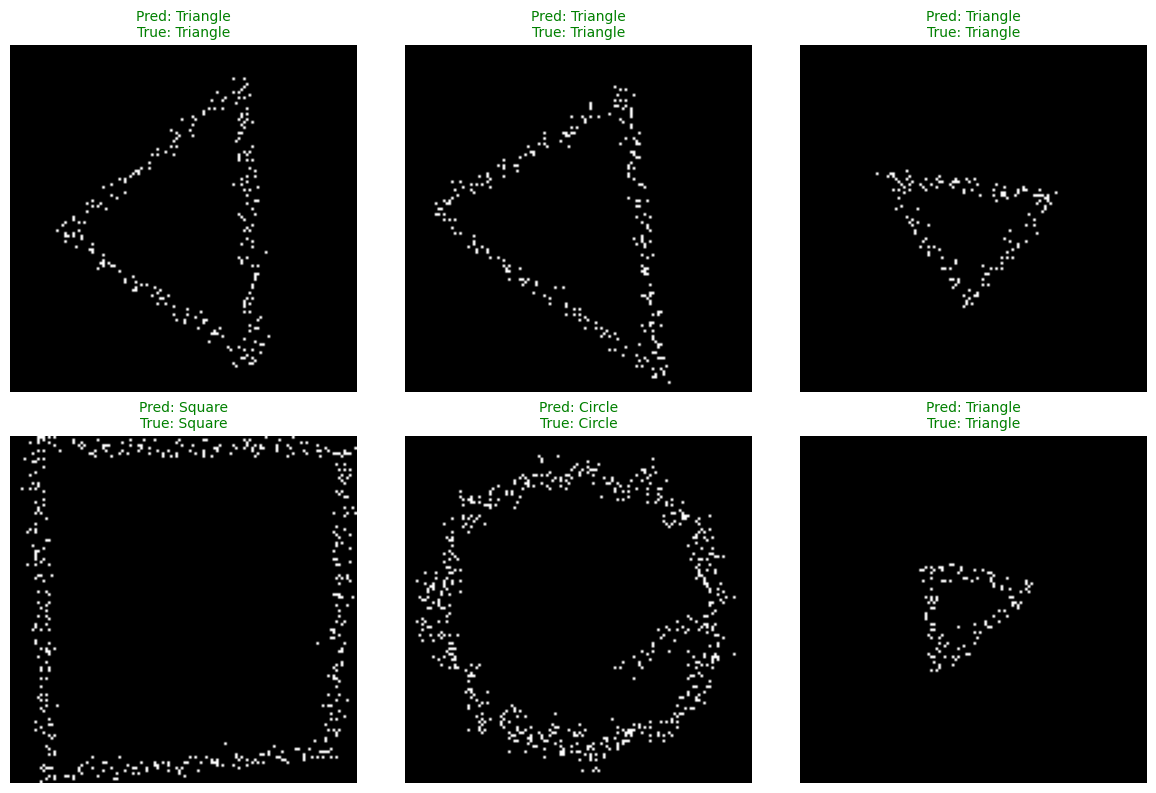

Epoch: 700 | Loss: 0.00302, Acc: 100.00% | Test Loss: 0.27851, Test Acc: 90.00%


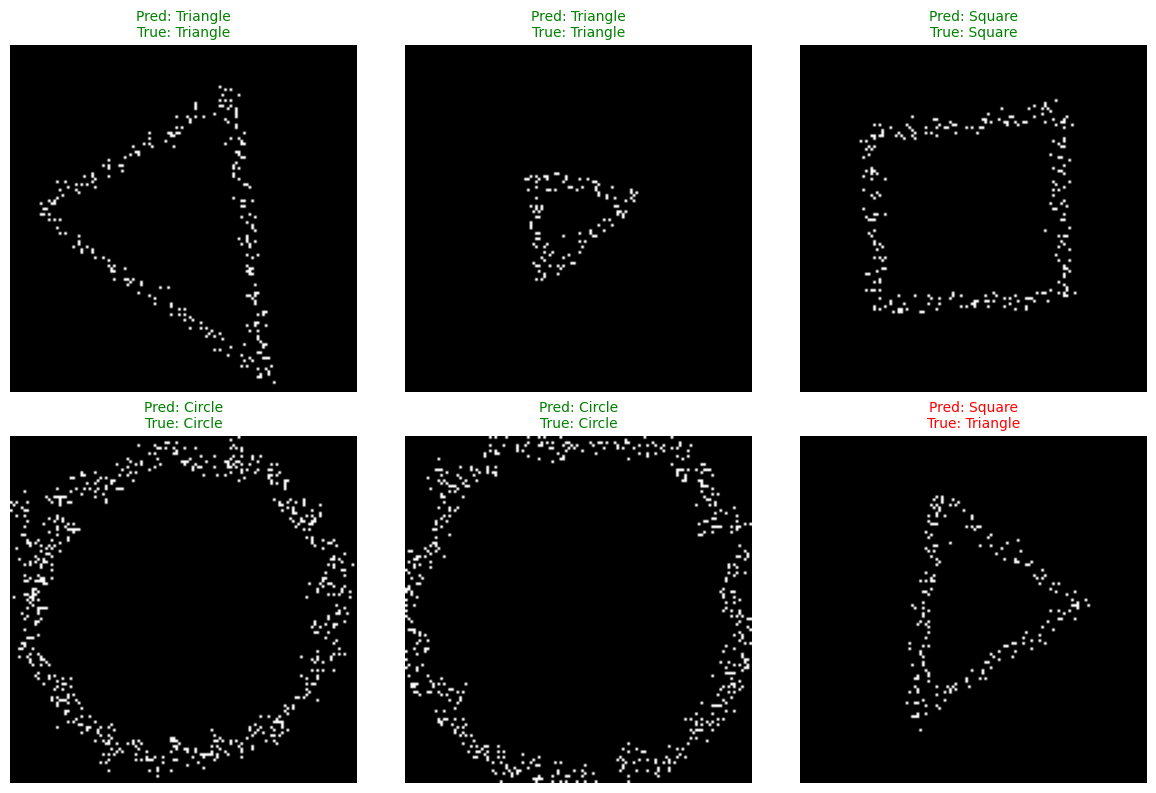

Epoch: 800 | Loss: 0.00299, Acc: 100.00% | Test Loss: 0.30722, Test Acc: 86.67%


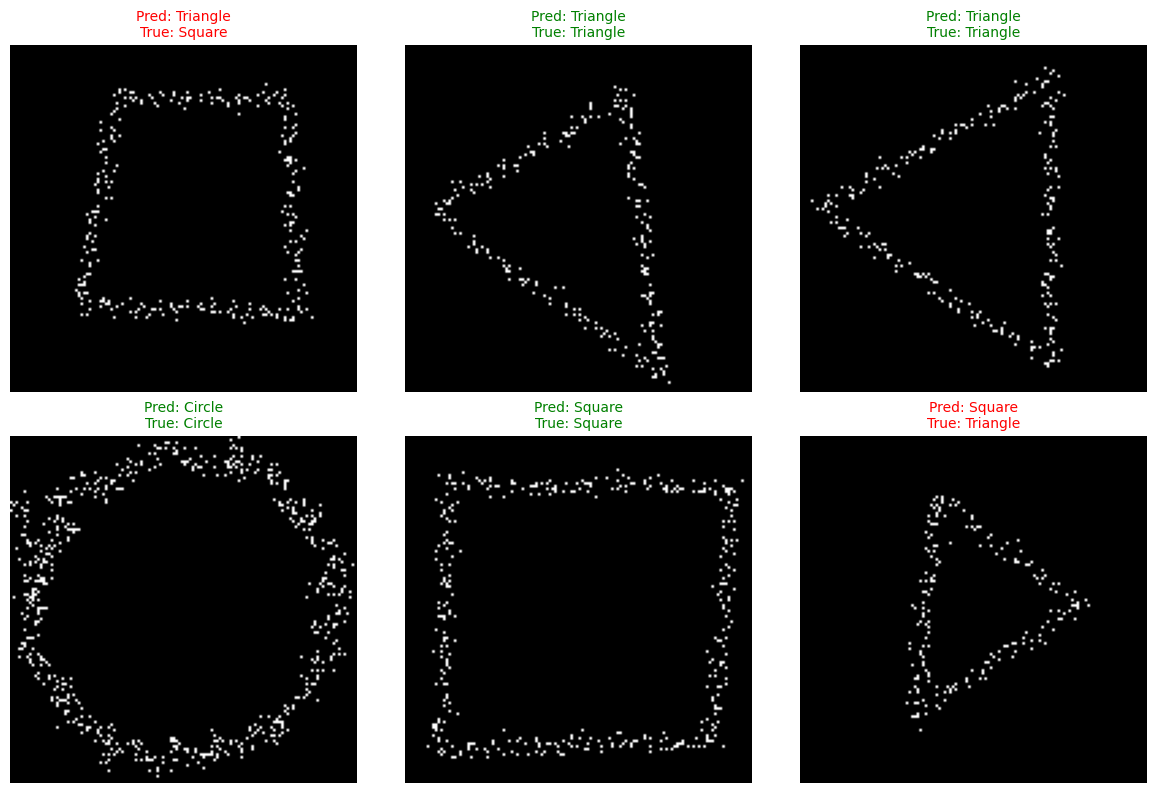

Epoch: 900 | Loss: 0.00348, Acc: 100.00% | Test Loss: 0.29825, Test Acc: 86.67%


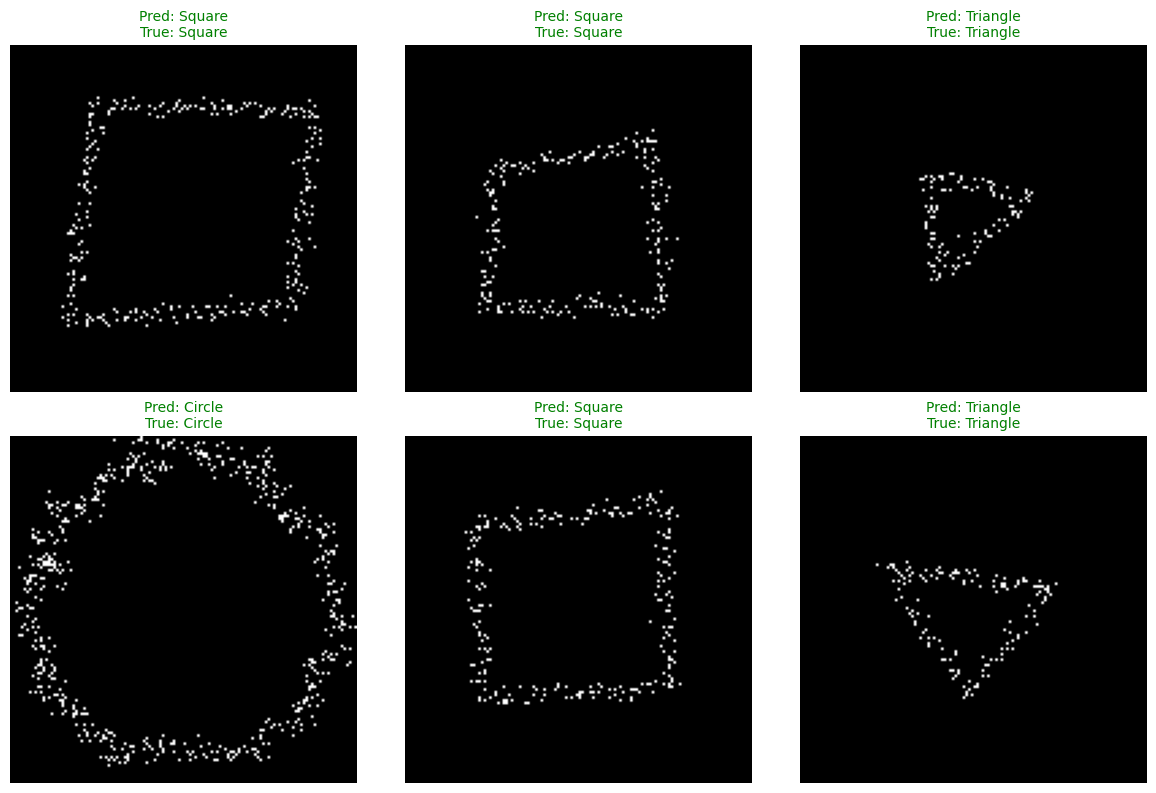

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 1000

# Put data to target device
X_blob_train, y_blob_train = images_tensor_train.to(device), labels_tensor_train.to(device)
X_blob_test, y_blob_test = images_tensor_test.to(device), labels_tensor_test.to(device)

# 클래스 이름 매핑
class_names = ["Triangle", "Square", "Circle"]

for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_blob_train)  # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # go from logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(image_true=y_blob_train, image_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(image_true=y_blob_test, image_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

        # Visualize every 10 epochs
        num_samples = 6  # 3x2 grid
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))

        # Random 6 samples
        indices = np.random.choice(len(X_blob_test), num_samples, replace=False)
        for i, idx in enumerate(indices):
            row = i // 3
            col = i % 3

            # Image extraction
            img = X_blob_test[idx, 0].cpu().detach().numpy()  # [1, 32, 32] -> [32, 32]

            # Predictoin vs Real
            pred_label = test_pred[idx].item()
            true_label = y_blob_test[idx].item()

            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')

            # Texts
            title = f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}"
            color = 'green' if pred_label == true_label else 'red'
            axes[row, col].set_title(title, color=color, fontsize=10)

        plt.tight_layout()
        plt.show()

In [ ]:
# Make predictions
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[ 2.4944,  0.4635, -2.8522],
        [-1.3229,  4.2497, -2.7976],
        [-2.5480,  5.1203, -2.4090],
        [ 4.0469, -1.6190, -2.3135],
        [ 0.7282,  1.3009, -1.8919],
        [-0.4558,  1.8431, -1.2813],
        [ 1.4796,  0.5021, -1.8652],
        [-2.2072,  4.1198, -1.7392],
        [-1.1425,  3.1723, -1.8368],
        [ 1.3057,  0.2514, -1.4246]])

In [ ]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(image_true=y_blob_test, image_pred=y_preds)}%")

Predictions: tensor([0, 1, 1, 0, 1, 1, 0, 1, 1, 0])
Labels: tensor([1, 1, 1, 0, 1, 0, 1, 1, 1, 0])
Test accuracy: 86.66666666666667%
